<a href="https://colab.research.google.com/github/Hashmi-78/cfpb-complaint-routing/blob/main/CFPB_01_data_and_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CFPB Complaint Routing & Trend Detection — Phase 1: Data & EDA
**Goal:** Route a consumer complaint narrative to the right product team, and surface emerging complaint trends.

**Phase 1 (this notebook):** load the CFPB Consumer Complaint Database, build a manageable sample of complaints *with narratives*, clean the labels, and explore the data.
Output: `cfpb_sample.parquet` saved to Google Drive for later phases.

> **Data provenance.** In September 2026 the CFPB stopped publishing consumer complaint narratives — the official export no longer contains the narrative column. This project uses an **archived snapshot (Aug 2026)** mirrored on Hugging Face: [`vivekkopthsd/cfpb-consumer-complaints`](https://huggingface.co/datasets/vivekkopthsd/cfpb-consumer-complaints). The structured (non-text) data is still published live by the CFPB and can be used for trend monitoring.

## 1. Setup

In [ ]:
import os, zipfile, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)
SEED = 42

# Mount Drive so the processed sample survives runtime resets
from google.colab import drive
drive.mount('/content/drive')
OUT_DIR = '/content/drive/MyDrive/cfpb-complaint-routing'
os.makedirs(OUT_DIR, exist_ok=True)

Mounted at /content/drive


## 2. Download the archived snapshot
The official CFPB export no longer includes narratives, so we pull the archived parquet (~1 GB) from Hugging Face. We never load it all at once — we stream it in record batches.

In [ ]:
from huggingface_hub import hf_hub_download
import pyarrow.parquet as pq
REPO = "vivekkopthsd/cfpb-consumer-complaints"
PQ = hf_hub_download(REPO, "complaints.parquet", repo_type="dataset", local_dir="/content/data")
pf = pq.ParquetFile(PQ)
print(f"{os.path.getsize(PQ)/1e9:.2f} GB | {pf.metadata.num_rows:,} rows | {pf.metadata.num_row_groups} row groups")
print(pf.schema_arrow)

complaints.parquet: reconstructing file:   0%|          |  0.00B / 1.02GB            

complaints.parquet: downloading bytes:           |  0.00B            

1.02 GB | 17,021,062 rows | 17 row groups
date_received: timestamp[us]
product: large_string
sub_product: large_string
issue: large_string
sub_issue: large_string
narrative: large_string
company_public_response: large_string
company: large_string
state: large_string
zip_code: large_string
tags: large_string
submitted_via: large_string
date_sent_to_company: timestamp[us]
company_response: large_string
timely_response: large_string
complaint_id: large_string
-- schema metadata --
pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 2197


## 3. Stream, filter to narratives, sample
We keep only complaints from **2020 onward** that have a consumer narrative (the text we'll classify), and take a random 15% of each batch to stay within Colab RAM.

In [ ]:
COLS = ["date_received", "product", "sub_product", "issue", "sub_issue", "narrative",
        "company", "state", "submitted_via", "company_response", "timely_response", "complaint_id"]
SAMPLE_FRAC = 0.15
START = pd.Timestamp("2020-01-01")

parts, total_rows, narr_rows = [], 0, 0
t0 = time.time()
for batch in pf.iter_batches(batch_size=250_000, columns=COLS):
    chunk = batch.to_pandas()
    total_rows += len(chunk)
    chunk["date_received"] = pd.to_datetime(chunk["date_received"], errors="coerce")
    chunk = chunk[chunk["narrative"].notna() & (chunk["narrative"].str.len() > 0)]
    chunk = chunk[chunk["date_received"] >= START]
    narr_rows += len(chunk)
    parts.append(chunk.sample(frac=SAMPLE_FRAC, random_state=SEED))
df = pd.concat(parts, ignore_index=True)
del parts
print(f"scanned {total_rows:,} rows | {narr_rows:,} with narrative since {START.date()} | sample {len(df):,} | {time.time()-t0:.0f}s")
print("date range in sample:", df["date_received"].min().date(), "->", df["date_received"].max().date())

scanned 17,021,062 rows | 3,344,316 with narrative since 2020-01-01 | sample 501,640 | 48s
date range in sample: 2020-01-01 -> 2026-07-21


In [ ]:
df.info(memory_usage="deep")
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501640 entries, 0 to 501639
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date_received     501640 non-null  datetime64[us]
 1   product           501640 non-null  object        
 2   sub_product       501635 non-null  object        
 3   issue             501640 non-null  object        
 4   sub_issue         470787 non-null  object        
 5   narrative         501640 non-null  object        
 6   company           501640 non-null  object        
 7   state             499867 non-null  object        
 8   submitted_via     501640 non-null  object        
 9   company_response  501638 non-null  object        
 10  timely_response   501640 non-null  object        
 11  complaint_id      501640 non-null  object        
dtypes: datetime64[us](1), object(11)
memory usage: 845.2 MB


,date_received,product,sub_product,issue,sub_issue,narrative,company,state,submitted_via,company_response,timely_response,complaint_id
0,2026-06-12,"Money transfer, virtual currency, or money service",Mobile or digital wallet,Trouble accessing funds in your mobile or digital wallet,None,"On XX/XX/XXXX, XXXX resolved 7 disputes in my favor. {$400.00} was credited to my XXXX balance. The remaining {$1200.00}, across 5 payouts ( Payout IDs XXXX, XXXX, XXXX, XXXX, XXXX ), was never re...","Paypal Holdings, Inc",NY,Web,Closed with explanation,Yes,23138500
1,2026-06-10,"Money transfer, virtual currency, or money service",Mobile or digital wallet,"Managing, opening, or closing your mobile wallet account",None,"On XX/XX/XXXX, I attempted to register a brand-new Cash App mobile wallet profile for the very first time in my life. I went through the standard identity verification protocol by providing my uni...","Block, Inc.",PA,Web,Closed with explanation,Yes,23059554
2,2026-06-10,"Payday loan, title loan, personal loan, or advance loan",Installment loan,Problem with a company's investigation into an existing problem,Their investigation did not fix an error on your report,"I am submitting this complaint regarding United Consumer Financial Services, account number XXXX, currently reporting as a charge-off on my XXXX, XXXX, and XXXX credit files. This account is being...",Scott Fetzer Financial Group Inc.,GA,Web,Closed with explanation,Yes,23073164


## 4. Clean the routing label (`product`)
CFPB renamed product categories over the years (e.g. *Credit reporting* → *Credit reporting, credit repair services, or other personal consumer reports*). We map them onto a stable set of routing teams.

In [ ]:
df["product"].value_counts()

,count
product,
Credit reporting or other personal consumer reports,250888
"Credit reporting, credit repair services, or other personal consumer reports",99753
Debt collection,50138
Checking or savings account,25149
"Money transfer, virtual currency, or money service",16805
Credit card,16079
Mortgage,12530
Credit card or prepaid card,11482
Vehicle loan or lease,6651


In [ ]:
PRODUCT_MAP = {
    "Credit reporting, credit repair services, or other personal consumer reports": "Credit reporting",
    "Credit reporting or other personal consumer reports": "Credit reporting",
    "Credit reporting": "Credit reporting",
    "Debt collection": "Debt collection",
    "Debt or credit management": "Debt collection",
    "Credit card or prepaid card": "Credit card",
    "Credit card": "Credit card",
    "Prepaid card": "Prepaid / money transfer",
    "Money transfer, virtual currency, or money service": "Prepaid / money transfer",
    "Money transfers": "Prepaid / money transfer",
    "Virtual currency": "Prepaid / money transfer",
    "Checking or savings account": "Bank account",
    "Bank account or service": "Bank account",
    "Mortgage": "Mortgage",
    "Vehicle loan or lease": "Vehicle loan",
    "Consumer Loan": "Vehicle loan",
    "Student loan": "Student loan",
    "Payday loan, title loan, or personal loan": "Personal / payday loan",
    "Payday loan, title loan, personal loan, or advance loan": "Personal / payday loan",
    "Payday loan": "Personal / payday loan",
}
df["team"] = df["product"].map(PRODUCT_MAP)
unmapped = df.loc[df["team"].isna(), "product"].value_counts()
print("unmapped products:\n", unmapped)
df["team"] = df["team"].fillna("Other")
team_counts = df["team"].value_counts()
team_counts

unmapped products:
 Series([], Name: count, dtype: int64)


,count
team,
Credit reporting,350641
Debt collection,50920
Credit card,27561
Bank account,25149
Prepaid / money transfer,18358
Mortgage,12530
Vehicle loan,6651
Student loan,5607
Personal / payday loan,4223


## 5. Text cleaning
CFPB redacts PII as `XXXX` / `XX/XX/XXXX`. These tokens carry no signal, so we normalise them.

In [ ]:
import re
def clean_text(s):
    s = re.sub(r"X{2,}/X{2,}/(X{2,}|\d{2,4})", " ", s)   # redacted dates
    s = re.sub(r"\bX{2,}\b", " ", s)                      # redacted names/numbers
    s = re.sub(r"\{\$[\d,.]+\}", " <amount> ", s)          # {$1,234.00}
    s = re.sub(r"\s+", " ", s)
    return s.strip()
df["text"] = df["narrative"].map(clean_text)
df["n_words"] = df["text"].str.split().str.len()
df = df.drop_duplicates(subset="text")
df = df[df["n_words"] >= 10].reset_index(drop=True)
print(len(df))
df[["narrative", "text"]].head(2)

341860


,narrative,text
0,"On XX/XX/XXXX, XXXX resolved 7 disputes in my favor. {$400.00} was credited to my XXXX balance. The remaining {$1200.00}, across 5 payouts ( Payout IDs XXXX, XXXX, XXXX, XXXX, XXXX ), was never re...","On , resolved 7 disputes in my favor. <amount> was credited to my balance. The remaining <amount> , across 5 payouts ( Payout IDs , , , , ), was never received. states these funds were sent to my ..."
1,"On XX/XX/XXXX, I attempted to register a brand-new Cash App mobile wallet profile for the very first time in my life. I went through the standard identity verification protocol by providing my uni...","On , I attempted to register a brand-new Cash App mobile wallet profile for the very first time in my life. I went through the standard identity verification protocol by providing my unique person..."


## 6. EDA

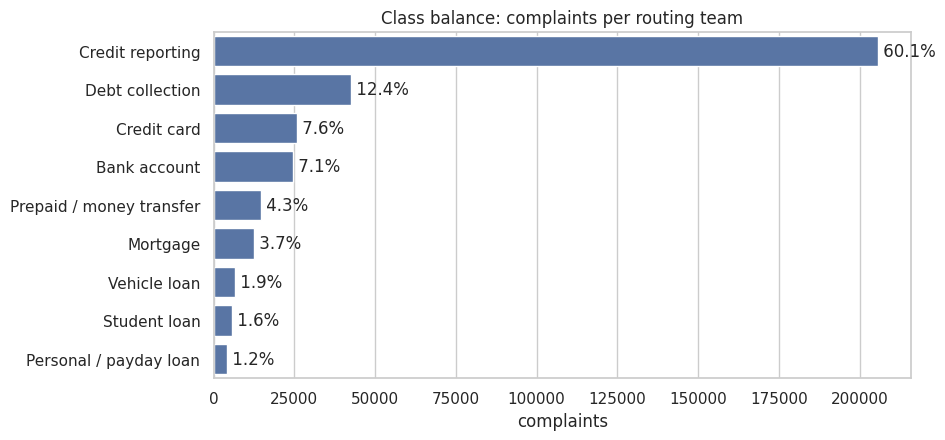

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
team_counts = df["team"].value_counts()
sns.barplot(x=team_counts.values, y=team_counts.index, ax=ax, color="#4C72B0")
for i, v in enumerate(team_counts.values):
    ax.text(v, i, f" {v/len(df):.1%}", va="center")
ax.set(title="Class balance: complaints per routing team", xlabel="complaints", ylabel="")
plt.show()

**Note:** heavy imbalance — credit reporting dominates. We'll need macro-F1 (not accuracy) and class weighting in Phase 2.

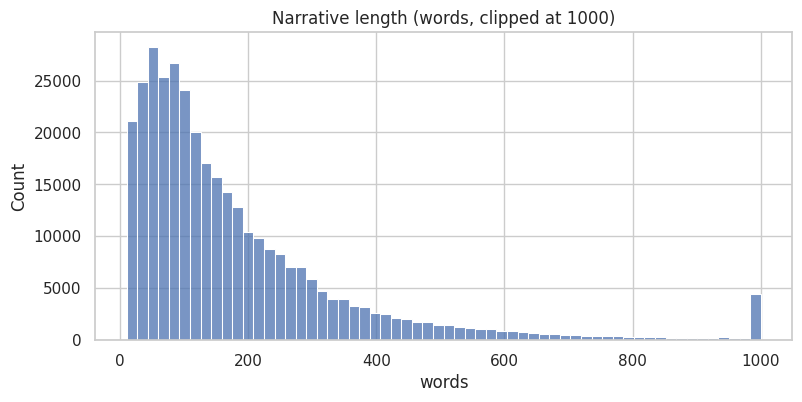

count    341860.0
mean        191.0
std         240.0
min          10.0
50%         126.0
90%         395.0
95%         551.0
99%        1081.0
max        6015.0
Name: n_words, dtype: float64
share > 400 words (~512 BERT tokens): 9.8%


,n_words
team,
Credit reporting,114.0
Prepaid / money transfer,116.0
Debt collection,119.0
Personal / payday loan,150.0
Bank account,156.0
Credit card,164.0
Student loan,165.0
Vehicle loan,175.0
Mortgage,207.0


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df["n_words"].clip(upper=1000), bins=60, ax=ax)
ax.set(title="Narrative length (words, clipped at 1000)", xlabel="words")
plt.show()
print(df["n_words"].describe(percentiles=[.5, .9, .95, .99]).round(0))
print(f"share > 400 words (~512 BERT tokens): {(df['n_words'] > 400).mean():.1%}")
df.groupby("team")["n_words"].median().sort_values()

Length matters for model choice: transformer models like BERT truncate at 512 tokens, so check how many narratives exceed that.

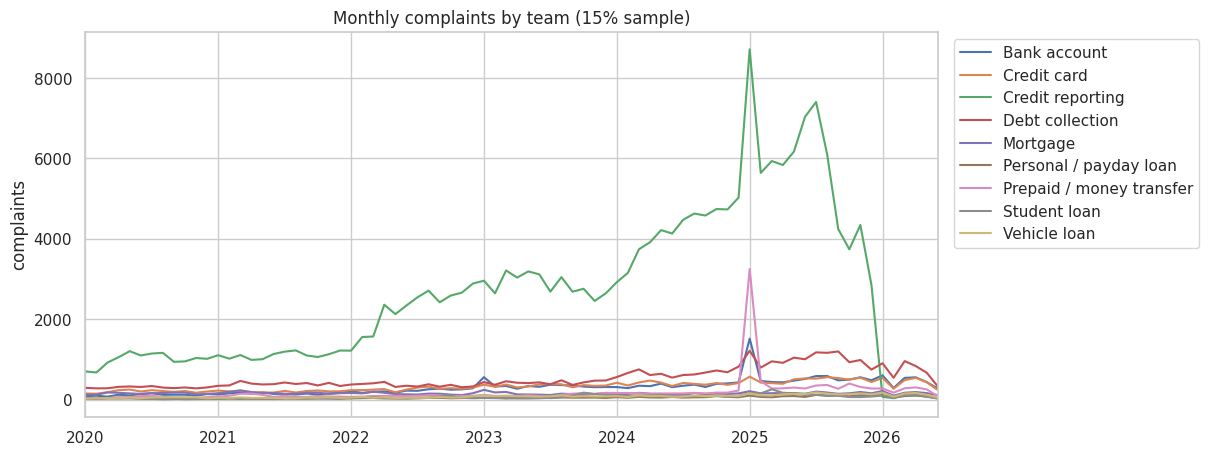

In [ ]:
monthly = (df.set_index("date_received").groupby("team").resample("MS").size()
           .unstack(0).fillna(0))
monthly = monthly.iloc[:-1]  # drop last partial month
fig, ax = plt.subplots(figsize=(11, 5))
monthly.plot(ax=ax, linewidth=1.5)
ax.set(title="Monthly complaints by team (15% sample)", ylabel="complaints", xlabel="")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.show()

This time series is the raw material for the **trend detection** part — spikes here are what we'll later flag automatically.

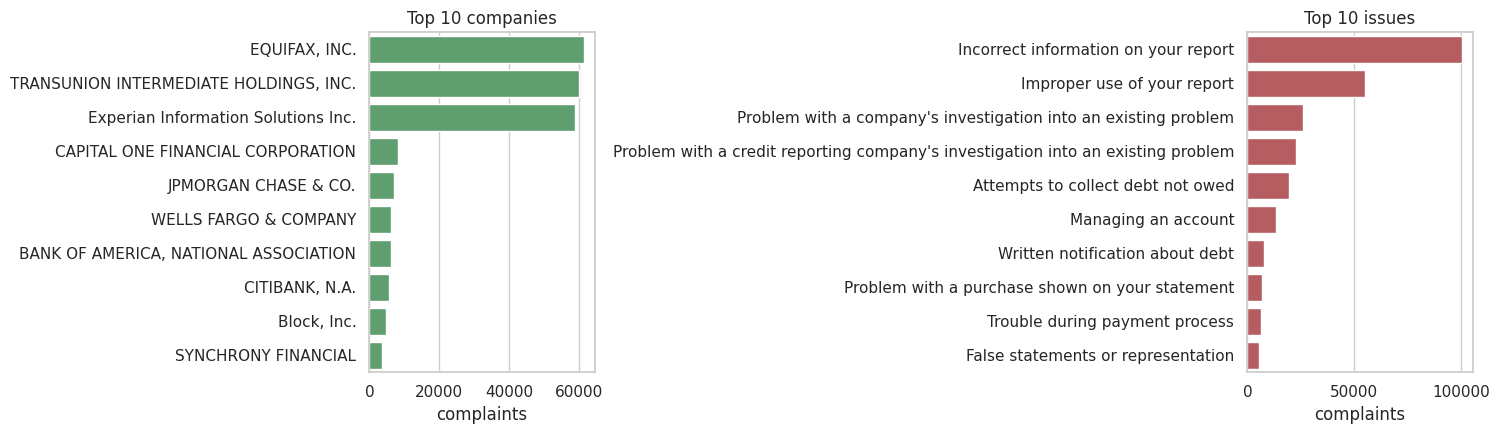

In [ ]:
top_cos = df["company"].value_counts().head(10)
top_issues = df["issue"].value_counts().head(10)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.barplot(x=top_cos.values, y=top_cos.index, ax=axes[0], color="#55A868")
axes[0].set(title="Top 10 companies", xlabel="complaints", ylabel="")
sns.barplot(x=top_issues.values, y=top_issues.index, ax=axes[1], color="#C44E52")
axes[1].set(title="Top 10 issues", xlabel="complaints", ylabel="")
plt.tight_layout(); plt.show()

In [ ]:
print("Issues per team:")
print(df.groupby("team")["issue"].nunique().sort_values(ascending=False))
for team in team_counts.index[:3]:
    print(f"\n--- {team} ---")
    print(df.loc[df.team == team, "text"].sample(1, random_state=SEED).iloc[0][:500])

Issues per team:
team
Personal / payday loan      31
Prepaid / money transfer    22
Credit card                 22
Credit reporting            19
Debt collection             13
Bank account                12
Student loan                12
Mortgage                    11
Vehicle loan                11
Name: issue, dtype: int64

--- Credit reporting ---
I am filing this complaint because my TransUnion credit report contains several inaccurate and harmful items that I have attempted to resolve through disputes, but no proper verification or corrections have been made. These errors are significantly impacting my credit score and financial well-being. The following accounts are either inaccurately reporting late payments or showing unauthorized inquiries that violate the Fair Credit Reporting Act ( FCRA ). requesting the Consumer Financial Protect

--- Debt collection ---
I have gotten repeated phone calls and voicemails from Consumer Portfolio Services at all times of the day. The debt they

## 7. Save the processed sample

In [ ]:
KEEP = ["complaint_id", "date_received", "product", "sub_product", "issue", "sub_issue",
        "team", "text", "n_words", "company", "state", "company_response", "timely_response"]
path = f"{OUT_DIR}/cfpb_sample.parquet"
df[KEEP].to_parquet(path, index=False)
print(f"saved {len(df):,} rows -> {path} ({os.path.getsize(path)/1e6:.1f} MB)")

saved 341,860 rows -> /content/drive/MyDrive/cfpb-complaint-routing/cfpb_sample.parquet (191.2 MB)


## Findings & next steps
- Label = `team` (product mapped to stable routing groups).
- Strong class imbalance → evaluate with macro-F1, use class weights / stratified splits.
- **Phase 2:** TF-IDF + Logistic Regression / Linear SVM baseline for routing.
- **Phase 3:** fine-tune a transformer (DistilBERT) and compare.
- **Phase 4:** trend detection — anomaly detection on monthly volumes per team/issue/company, plus topic modelling (BERTopic) for emerging issues.